# Imports and Reading data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [2]:
df = pd.read_csv('STO-const_decay.csv')

# Data understanding

In [3]:
df.shape

# 10000 rows and 5 columns as expected

(10000, 5)

In [4]:
df.head(5)

,optimizer_gain,dither_amplitude,dither_frequency,converged,convergence_time
0,0.001795,0.409215,0.762317,0,NaN
1,0.001567,0.457554,0.652944,0,NaN
2,0.082227,0.146464,0.618753,0,NaN
3,0.087334,0.482795,0.463045,0,NaN
4,0.039862,0.479012,0.594150,1,11.82


In [53]:
df.dtypes

optimizer_gain      float64
dither_amplitude    float64
dither_frequency    float64
converged             int64
convergence_time    float64
log10gain           float64
sinfre              float64
product             float64
dtype: object

# Data preparation

In [6]:
df.isna().sum()

# only the convergence_time has duplicated values(2843) so we do not need to drop any rows

optimizer_gain         0
dither_amplitude       0
dither_frequency       0
converged              0
convergence_time    2843
dtype: int64

# Feature understanding

Text(0, 0.5, 'Counts')

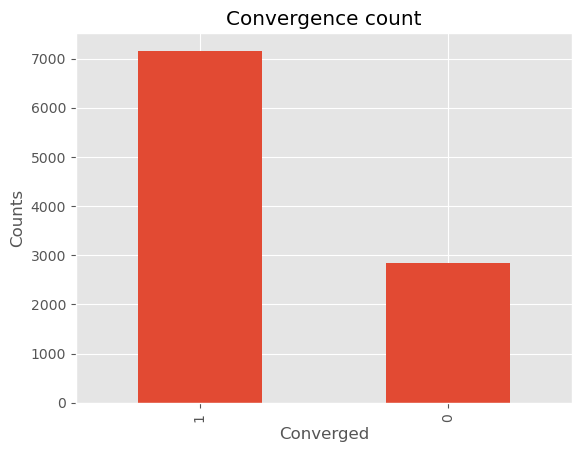

In [7]:
cv = df['converged'].value_counts().head(10).plot(kind = 'bar', title = 'Convergence count')

cv.set_xlabel('Converged')
cv.set_ylabel('Counts')

# More than 70% converged. I think this is a healthy spread as we care more about the converged combinations

Text(0, 0.5, 'Frequency')

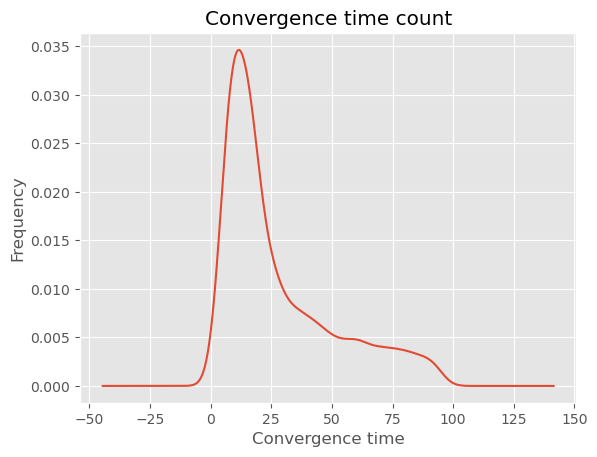

In [8]:
ct = df['convergence_time'].plot(kind = 'kde',
                title = 'Convergence time count')
ct.set_xlabel('Convergence time')
ct.set_ylabel('Frequency')

# Many combinations lead to convergence time < 12.5 seconds, which is really impressive

In [9]:
sum(df['convergence_time'] < 10)

# There are 1560 out of 10000 combinations that has the convergence_time < 10, which is extremely good

1560

In [10]:
sum(df['convergence_time'] < 5)

# 259 combinations have convergence time < 5. I see potential.


259

# Feature relationships

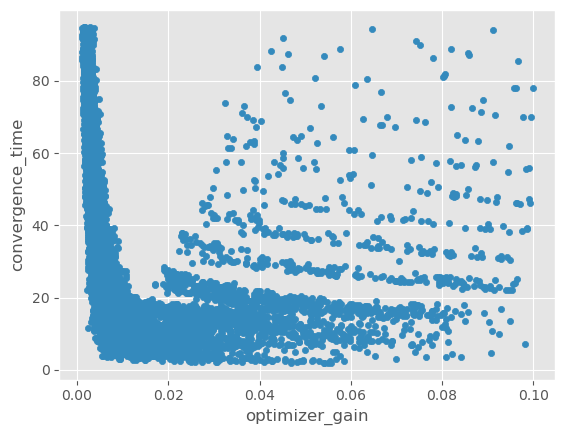

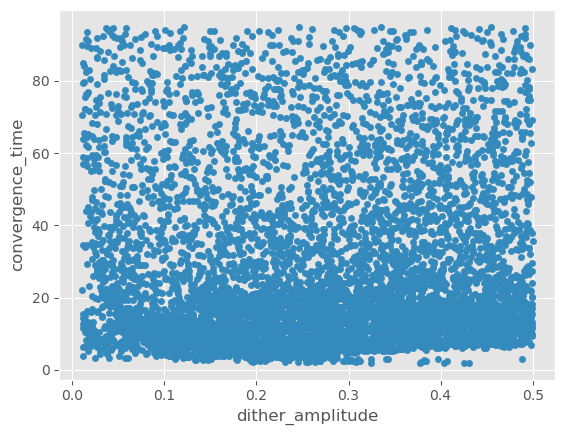

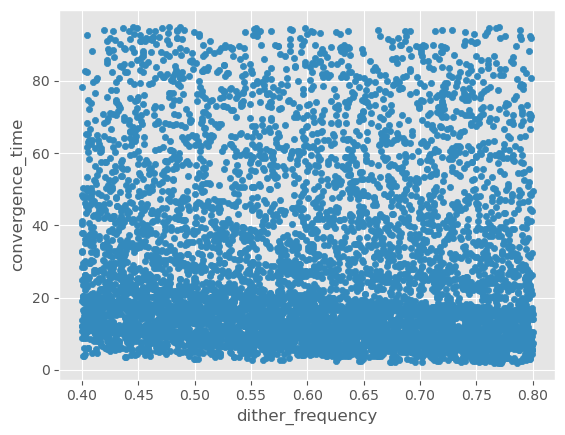

In [11]:
for i in range (df.shape[1] - 2):
    df.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()


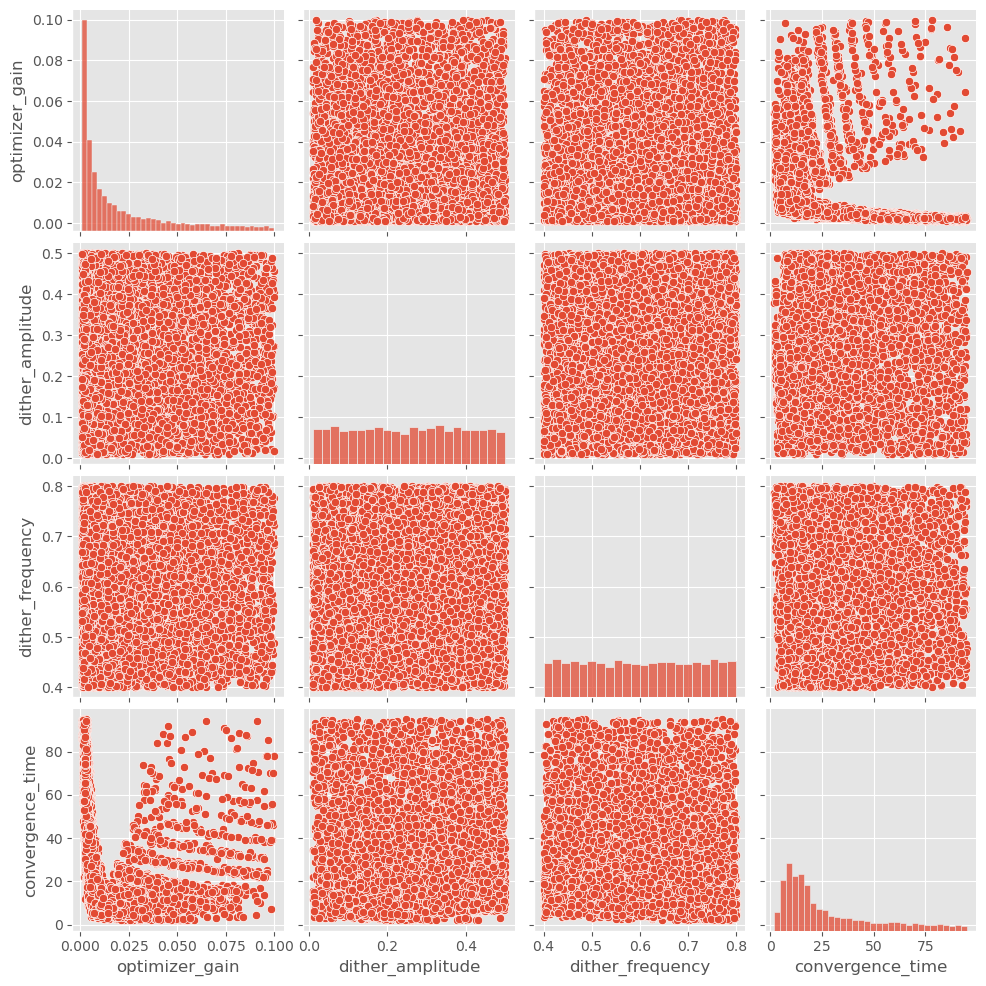

In [12]:
sns.pairplot(df,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()


<Axes: >

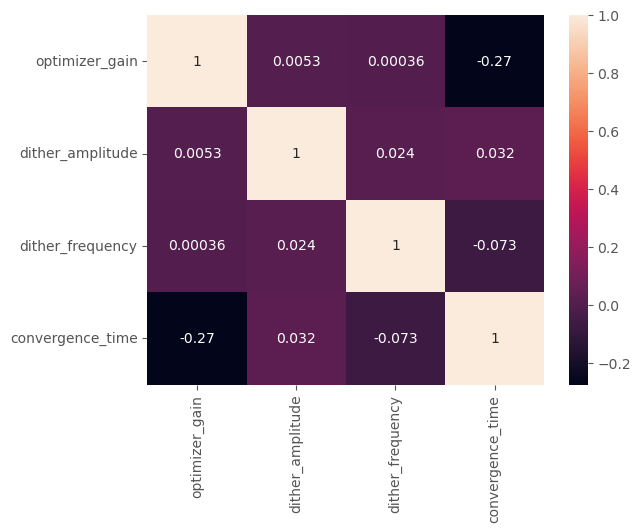

In [13]:
sns.heatmap(df.drop(columns = 'converged').corr(), annot = True)


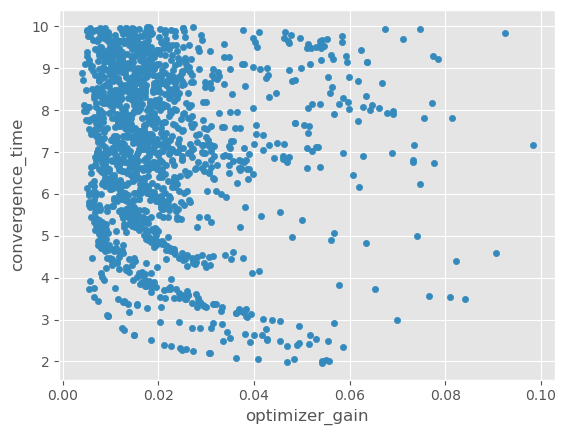

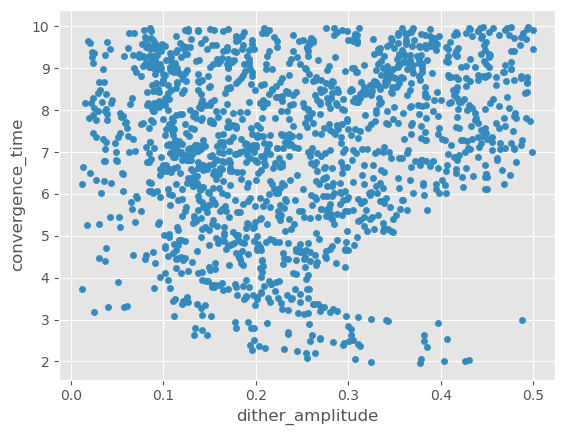

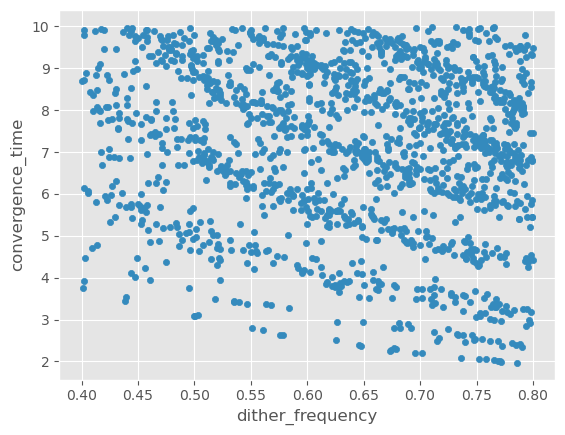

In [14]:
dfcut = df[df['convergence_time'] < 10]
for i in range (dfcut.shape[1] - 2):
    dfcut.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()


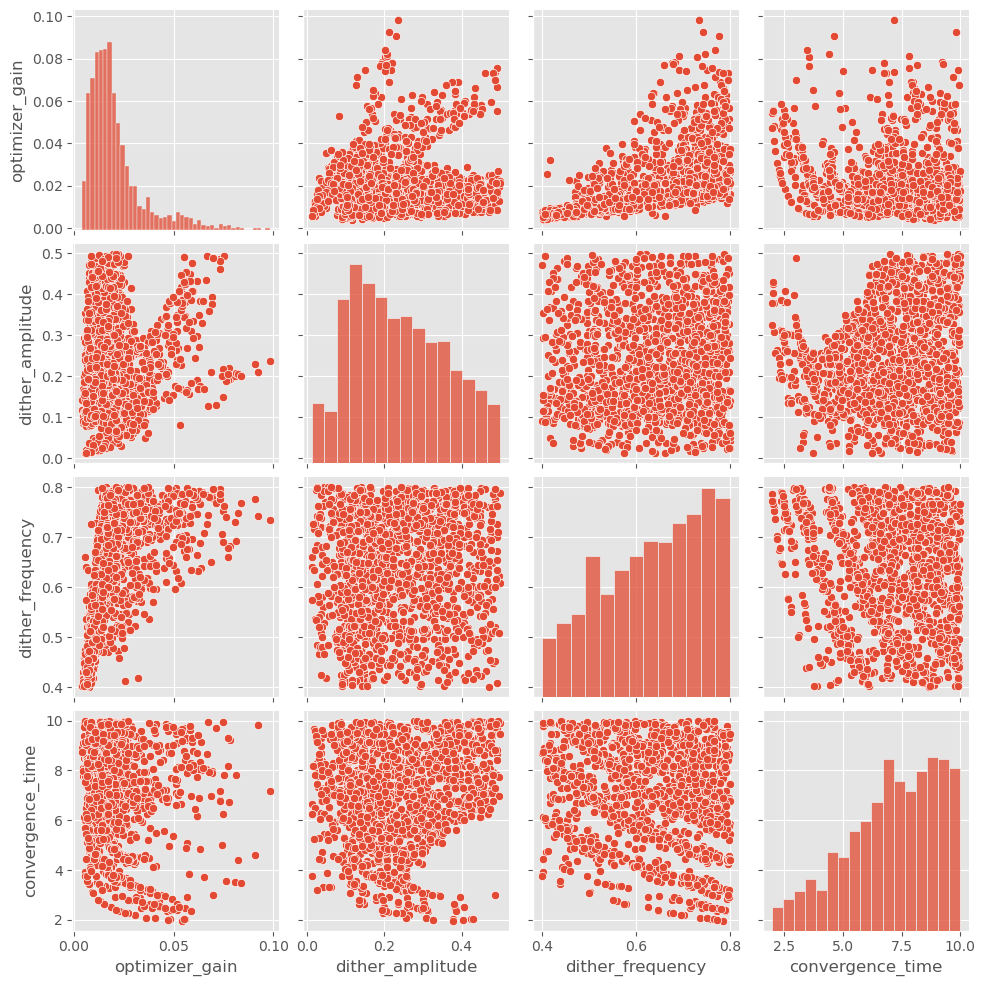

In [15]:
sns.pairplot(dfcut,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()


<Axes: >

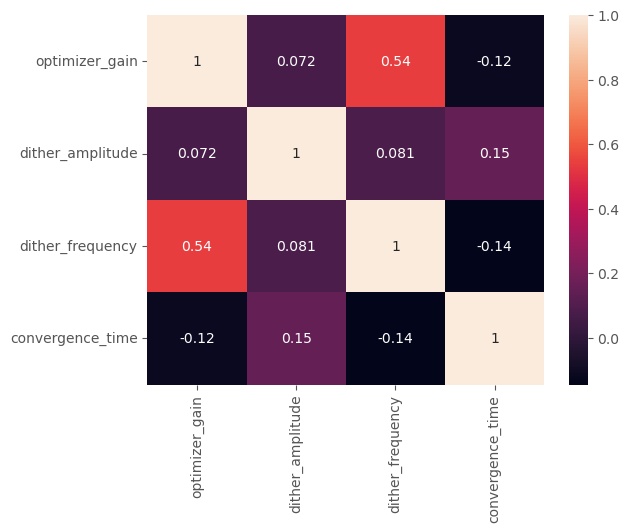

In [16]:
sns.heatmap(dfcut.drop(columns = 'converged').corr(), annot = True)


# Modelling: Classification

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score



Set 1 is the orginal dataset. 
Set 2 is set 1 with additional colummns: 'sinfre', 'log10gain' and 'product'.
Model 1 has 32-16-1 units
Model 2 has 64-32-1 units

In [19]:
# Create sets 1 for model 1

X11 = df.drop(columns=['convergence_time', 'converged'])
y11 = df['converged']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train11, X_, y_train11, y_ = train_test_split(X11, y11, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv11, X_test11, y_cv11, y_test11 = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [20]:
# Create model 1 for set 1
model11 = Sequential(
    [
        Dense(32, activation='relu', name="L1"),
        Dense(16, activation='relu', name="L2"),
        Dense(1, activation = 'linear', name = "L3")  
    ]
)

Epoch 1/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5939 - val_loss: 0.5836
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5365 - val_loss: 0.4920
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4730 - val_loss: 0.4414
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4156 - val_loss: 0.3960
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3830 - val_loss: 0.3861
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3549 - val_loss: 0.3188
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3093 - val_loss: 0.2959
Epoch 8/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2798 - val_loss: 0.2646
Epoch 9/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2482 - val_loss: 0.2295
Epoch 10/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2361 - val_loss: 0.2126
Epoch 11/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2351 - val_loss: 0.1902
Epoch 12/200
188/188 ━━━━━━━━━━━━━━━━━━━━

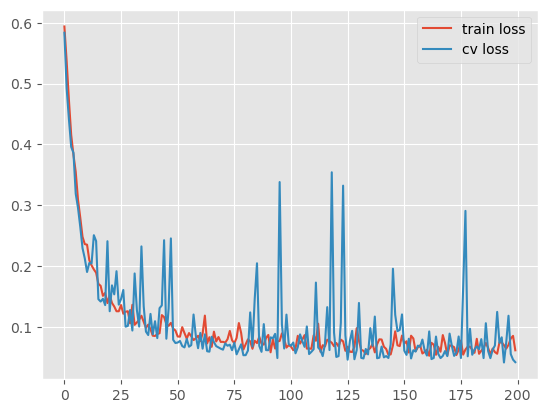

In [21]:
# Train model 1 with sets 1

model11.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history11 = model11.fit(X_train11, 
                     y_train11, 
                     epochs=200, 
                     validation_data=(X_cv11, y_cv11))
plt.plot(history11.history['loss'], label='train loss')
plt.plot(history11.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [22]:
logits11 = model11.predict(X_cv11)
probs11 = tf.sigmoid(logits11).numpy() # convert logit to probability
y_pred11 = (probs11 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy11 = accuracy_score(y_cv11, y_pred11)
print(f"CV accuracy: {accuracy11:.3f}")

# ~97% accuracy. Nice!

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
CV accuracy: 0.987


In [23]:
print(confusion_matrix(y_cv11, y_pred11))
print(classification_report(y_cv11, y_pred11))

# The recall for "0" is a bit lower than expected, at only 0.93

[[ 563   17]
 [  10 1410]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       580
           1       0.99      0.99      0.99      1420

    accuracy                           0.99      2000
   macro avg       0.99      0.98      0.98      2000
weighted avg       0.99      0.99      0.99      2000



In [24]:
train_logits11 = model11.predict(X_train11)
train_probs11 = tf.sigmoid(train_logits11).numpy()
train_pred11 = (train_probs11 > 0.5).astype(int).flatten()
train_acc11 = accuracy_score(y_train11, train_pred11)
print(f"Train accuracy: {train_acc11:.3f}")

# Both CV and training data achieve ~97%, although train accuracy is a bit higher

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Train accuracy: 0.987


I would still try to see if I can achieve even a higher accuracy

In [25]:
# Adding more features
df['log10gain'] = np.log10(df['optimizer_gain'])
df['sinfre'] = np.sin(df['dither_frequency'])
df['product'] = df['optimizer_gain'] * df['dither_amplitude'] * df['sinfre']

In [26]:
# Create set 2 for model 1

X12 = df.drop(columns=['convergence_time', 'converged'])
y12 = df['converged']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train12, X_, y_train12, y_ = train_test_split(X12, y12, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv12, X_test12, y_cv12, y_test12 = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [27]:
# Create model 1 for set 2
model12 = Sequential(
    [
        Dense(32, activation='relu', name="L1"),
        Dense(16, activation='relu', name="L2"),
        Dense(1, activation = 'linear', name = "L3")  
    ]
)

Epoch 1/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.5766 - val_loss: 0.5148
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.3933 - val_loss: 0.2668
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.2366 - val_loss: 0.1841
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2021 - val_loss: 0.2204
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1826 - val_loss: 0.2047
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1786 - val_loss: 0.3836
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1916 - val_loss: 0.1669
Epoch 8/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1663 - val_loss: 0.2042
Epoch 9/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1616 - val_loss: 0.1531
Epoch 10/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1623 - val_loss: 0.1840
Epoch 11/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1629 - val_loss: 0.1771
Epoch 12/200
188/188 ━━━━━━━━━━━━━

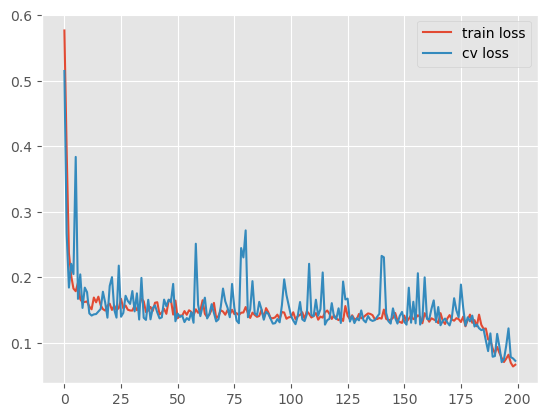

In [28]:
# Train model 1 with set 2

model12.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history12 = model12.fit(X_train12, 
                     y_train12, 
                     epochs=200, 
                     validation_data=(X_cv12, y_cv12))
plt.plot(history12.history['loss'], label='train loss')
plt.plot(history12.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [29]:
logits12 = model12.predict(X_cv12)
probs12 = tf.sigmoid(logits12).numpy() # convert logit to probability
y_pred12 = (probs12 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy12 = accuracy_score(y_cv12, y_pred12)
print(f"CV accuracy: {accuracy12:.3f}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
CV accuracy: 0.972


In [30]:
print(confusion_matrix(y_cv12, y_pred12))
print(classification_report(y_cv12, y_pred12))

[[ 562   18]
 [  39 1381]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       580
           1       0.99      0.97      0.98      1420

    accuracy                           0.97      2000
   macro avg       0.96      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [31]:
train_logits12 = model12.predict(X_train12)
train_probs12 = tf.sigmoid(train_logits12).numpy()
train_pred12 = (train_probs12 > 0.5).astype(int).flatten()
train_acc12 = accuracy_score(y_train12, train_pred12)
print(f"Train accuracy: {train_acc12:.3f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Train accuracy: 0.971


The accuracy actually improved to 98%. I would push a bit further cause why not, I have the code here already.

In [32]:
# Create sets 2 for model 2

X22 = df.drop(columns=['convergence_time', 'converged'])
y22 = df['converged']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train22, X_, y_train22, y_ = train_test_split(X22, y22, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv22, X_test22, y_cv22, y_test22 = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [33]:
# Create model 2 for set 2
model22 = Sequential(
    [
        Dense(64, activation='relu', name="L1"),
        Dense(32, activation='relu', name="L2"),
        Dense(16, activation='relu', name="L3"),
        Dense(1, activation = 'linear', name = "L4")  
    ]
)

Epoch 1/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.5480 - val_loss: 0.3790
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2804 - val_loss: 0.1879
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2019 - val_loss: 0.1645
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1799 - val_loss: 0.1904
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1707 - val_loss: 0.1455
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1335 - val_loss: 0.1138
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1072 - val_loss: 0.1298
Epoch 8/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1007 - val_loss: 0.1395
Epoch 9/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1108 - val_loss: 0.0879
Epoch 10/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1212 - val_loss: 0.1021
Epoch 11/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0924 - val_loss: 0.0719
Epoch 12/200
188/188 ━━━━━━━━━

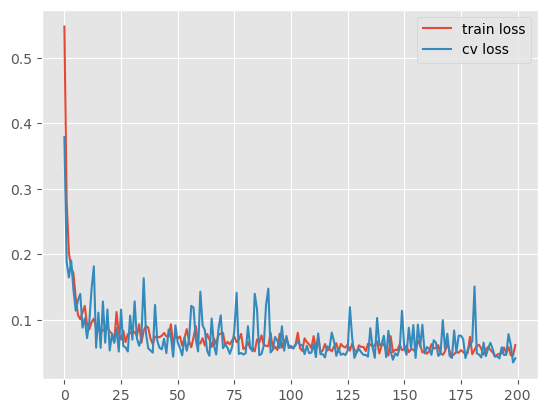

In [34]:
# Train model 2 with set 2

model22.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history22 = model22.fit(X_train22, 
                     y_train22, 
                     epochs=200, 
                     validation_data=(X_cv22, y_cv22))
plt.plot(history22.history['loss'], label='train loss')
plt.plot(history22.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [35]:
logits22 = model22.predict(X_cv22)
probs22 = tf.sigmoid(logits22).numpy() # convert logit to probability
y_pred22 = (probs22 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy22 = accuracy_score(y_cv22, y_pred22)
print(f"CV accuracy: {accuracy22:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
CV accuracy: 0.984


In [36]:
print(confusion_matrix(y_cv22, y_pred22))
print(classification_report(y_cv22, y_pred22))


[[ 559   21]
 [  12 1408]]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       580
           1       0.99      0.99      0.99      1420

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



In [37]:
train_logits22 = model22.predict(X_train22)
train_probs22 = tf.sigmoid(train_logits22).numpy()
train_pred22 = (train_probs22 > 0.5).astype(int).flatten()
train_acc22 = accuracy_score(y_train22, train_pred22)
print(f"Train accuracy: {train_acc22:.3f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Train accuracy: 0.987


It seems like it does improve. I think there is still room for improvement, but we would have to analyse the wrong predictions first.

In [55]:
# Find where the false positives are
false_positive11 = (y_pred11 == 1) & (y_cv11 == 0)
X_cv11_df = pd.DataFrame(X_cv11, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv11_df[false_positive11].describe())

false_positive12 = (y_pred12 == 1) & (y_cv12 == 0)
X_cv12_df = pd.DataFrame(X_cv12, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv12_df[false_positive12].describe())

false_positive22 = (y_pred22 == 1) & (y_cv22 == 0)
X_cv22_df = pd.DataFrame(X_cv22, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv22_df[false_positive22].describe())

       optimizer_gain  dither_amplitude  dither_frequency
count       17.000000         17.000000         17.000000
mean         0.027593          0.193080          0.508062
std          0.027096          0.103603          0.127176
min          0.001072          0.022894          0.400028
25%          0.001582          0.114534          0.414553
50%          0.028285          0.190087          0.444018
75%          0.033850          0.239315          0.541371
max          0.099766          0.402034          0.784265
       optimizer_gain  dither_amplitude  dither_frequency
count       18.000000         18.000000         18.000000
mean         0.015114          0.158199          0.514512
std          0.014360          0.098573          0.124882
min          0.001302          0.010035          0.400028
25%          0.001841          0.077275          0.417300
50%          0.008673          0.185973          0.471429
75%          0.029670          0.231629          0.590928
max          0

In [ ]:
# Merge all the false positives into 1 table

fp11 = X_cv11_df[false_positive11]
fp12 = X_cv12_df[false_positive12]
fp22 = X_cv22_df[false_positive22]

fp = pd.concat([fp11, fp12, fp22], ignore_index=True)
print(fp.describe())

       optimizer_gain  dither_amplitude  dither_frequency
count       56.000000         56.000000         56.000000
mean         0.023080          0.171735          0.517331
std          0.022027          0.101065          0.121560
min          0.001072          0.010035          0.400028
25%          0.001744          0.082995          0.419293
50%          0.028257          0.181859          0.483875
75%          0.033451          0.236014          0.570110
max          0.099766          0.402034          0.792507


In [ ]:
# Drop duplicated rows of fp

fp = fp.loc[~fp.duplicated()].reset_index(drop = True)
print(fp.describe())

       optimizer_gain  dither_amplitude  dither_frequency
count       28.000000         28.000000         28.000000
mean         0.023696          0.172634          0.535366
std          0.026154          0.106919          0.125825
min          0.001072          0.010035          0.400028
25%          0.001744          0.082995          0.424374
50%          0.015863          0.179326          0.491996
75%          0.034518          0.236839          0.608117
max          0.099766          0.402034          0.792507


In [54]:
# Find where the false negatives are
false_negative11 = (y_pred11 == 0) & (y_cv11 == 1)
X_cv11_df = pd.DataFrame(X_cv11, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv11_df[false_negative11].describe())

false_negative12 = (y_pred12 == 0) & (y_cv12 == 1)
X_cv12_df = pd.DataFrame(X_cv12, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv12_df[false_negative12].describe())

false_negative22 = (y_pred22 == 0) & (y_cv22 == 1)
X_cv22_df = pd.DataFrame(X_cv22, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv22_df[false_negative22].describe())

       optimizer_gain  dither_amplitude  dither_frequency
count       10.000000         10.000000         10.000000
mean         0.032838          0.115868          0.549091
std          0.029264          0.148156          0.092041
min          0.003775          0.013979          0.408568
25%          0.009764          0.025520          0.484320
50%          0.023591          0.060283          0.551963
75%          0.048357          0.143540          0.600294
max          0.082011          0.493866          0.699379
       optimizer_gain  dither_amplitude  dither_frequency
count       39.000000         39.000000         39.000000
mean         0.043239          0.221119          0.532172
std          0.022061          0.150722          0.070988
min          0.001279          0.015893          0.408568
25%          0.036744          0.079016          0.478412
50%          0.045405          0.209021          0.522349
75%          0.053310          0.334007          0.573305
max          0

In [56]:
# Merge all the false negatives into 1 table

fn11 = X_cv11_df[false_negative11]
fn12 = X_cv12_df[false_negative12]
fn22 = X_cv22_df[false_negative22]

fn = pd.concat([fn11, fn12, fn22], ignore_index=True)
print(fn.describe())

       optimizer_gain  dither_amplitude  dither_frequency
count       61.000000         61.000000         61.000000
mean         0.043464          0.224718          0.535561
std          0.023767          0.165647          0.074971
min          0.001279          0.013979          0.408568
25%          0.033817          0.060352          0.474744
50%          0.043325          0.209021          0.534291
75%          0.054178          0.392058          0.581579
max          0.085651          0.493866          0.699379


In [57]:
# Drop duplicated rows of fn

fn = fn.loc[~fn.duplicated()].reset_index(drop = True)
print(fn.describe())

       optimizer_gain  dither_amplitude  dither_frequency
count       41.000000         41.000000         41.000000
mean         0.043033          0.222398          0.532322
std          0.022920          0.156003          0.071266
min          0.001279          0.013979          0.408568
25%          0.036455          0.077406          0.474744
50%          0.045405          0.209021          0.522349
75%          0.054178          0.340332          0.574247
max          0.085651          0.493866          0.699379


In [58]:
fp

,optimizer_gain,dither_amplitude,dither_frequency
0,0.028257,0.181859,0.412940
1,0.036519,0.236014,0.444018
2,0.066267,0.402034,0.572566
3,0.054276,0.170726,0.535254
4,0.017910,0.022894,0.775968
5,0.028285,0.239315,0.400028
6,0.001072,0.085200,0.420873
7,0.031067,0.209788,0.414553
8,0.033850,0.114534,0.491535
9,0.099766,0.274591,0.682767


I think it would be useful to plot a 3d plot to visualize where the false predictions are.

# Visualization

In [63]:
import plotly.express as px

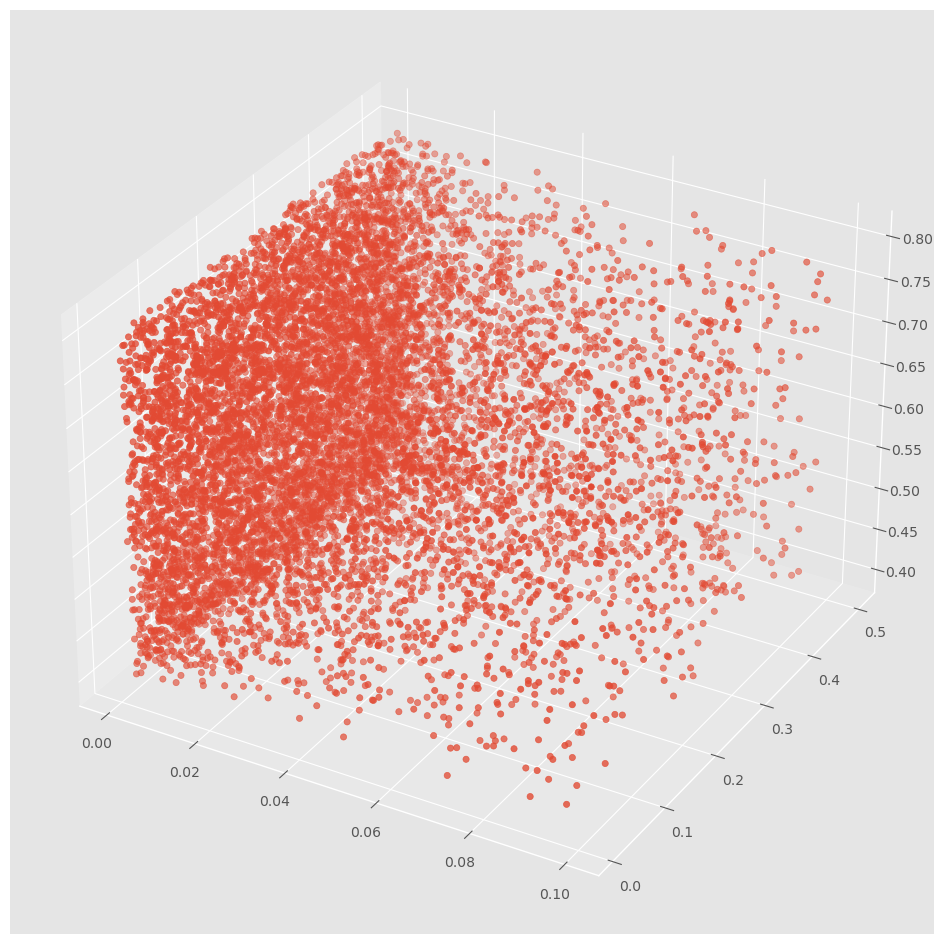

In [60]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')

x_axis = df['optimizer_gain']
y_axis = df['dither_amplitude']
z_axis = df['dither_frequency']


ax.scatter(x_axis, y_axis, z_axis)
plt.show()


In [77]:
fig = px.scatter_3d(df,
                    x = 'optimizer_gain',
                    y = 'dither_amplitude',
                    z = 'dither_frequency',
                    color = 'convergence_time',
                    title = '3D scatter',
                    labels = {'optimizer_gain' : 'Optimizer gain',
                              'dither_amplitude' : 'Dither amplitude',
                              'dither_frequency' : 'Dither Frequency'})
fig.update_traces(marker=dict(size=3))
fig.show()

In [ ]:
# Exporting the plot (put it comment as I would run the notebook all over every time I open)
# fig.write_html("3dscatter.html")